## CKD Dataset Project ML Modeling

#### import Librires

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Reasing Dataset

In [6]:
df_train = pd.read_csv('Testing_CKD_dataset.csv')

In [7]:
df_test = pd.read_csv('Testing_CKD_dataset.csv')

### EDA

In [8]:
df_train.head()

,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,38,0,33,114,78,78,0,10,117,...,97,4.677411,211,203,4,5.156141,No,No,Yes,No
1,Severe CKD (Stage 4),76,0,28,166,103,92,5,84,25,...,111,9.490302,194,210,2,7.922118,No,No,No,No
2,Healthy Kidney,63,0,33,109,79,98,0,17,109,...,125,6.023745,243,138,4,6.606848,No,No,No,Yes
3,Healthy Kidney,54,0,31,107,62,109,0,10,107,...,127,5.772014,163,276,4,6.651897,No,Yes,No,Yes
4,Healthy Kidney,20,0,20,111,63,92,0,17,97,...,127,8.483288,221,264,4,6.400641,No,Yes,Yes,No


### Checking Nulls

In [9]:
df_train.isnull().sum()

Target                      0
Age                         0
Gender                      0
BMI                         0
Systolic_BP                 0
Diastolic_BP                0
Heart_Rate                  0
Serum_Creatinine            0
Blood_Urea_Nitrogen         0
eGFR                        0
Urine_Albumin               0
Urine_Protein               0
Albumin_Creatinine_Ratio    0
Urine_Specific_Gravity      0
Sodium                      0
Potassium                   0
Calcium                     0
Phosphorus                  0
Chloride                    0
Bicarbonate                 0
Hemoglobin                  0
RBC_Count                   0
WBC_Count                   0
Platelet_Count              0
Packed_Cell_Volume          0
Blood_Glucose_Random        0
Fasting_Glucose             0
HbA1c                       0
Cholesterol                 0
Triglycerides               0
Serum_Albumin               0
Total_Protein               0
Diabetes                    0
Hypertensi

In [10]:
df_train.describe()

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,Urine_Albumin,...,WBC_Count,Platelet_Count,Packed_Cell_Volume,Blood_Glucose_Random,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein
count,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.0000,4800.000000,4800.000000,4800.000000,4800.000000,...,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000
mean,52.037083,0.510625,26.000833,113.263542,75.198125,84.8125,0.615833,21.627917,91.892292,58.843958,...,7466.751667,299515.230417,42.272292,134.303542,99.475000,6.981420,214.884583,201.237917,3.606042,6.504734
std,18.794795,0.499939,4.948705,19.021180,11.988556,14.3716,1.451989,20.657173,26.660083,135.997999,...,2029.807126,85795.588383,5.498965,37.316957,17.175746,1.714337,37.241641,57.471281,0.756995,0.859411
min,20.000000,0.000000,18.000000,90.000000,60.000000,60.0000,0.000000,7.000000,5.000000,0.000000,...,4000.000000,150055.000000,20.000000,70.000000,70.000000,4.003597,150.000000,100.000000,1.000000,5.000294
25%,36.000000,0.000000,22.000000,100.000000,66.000000,72.0000,0.000000,11.000000,90.000000,6.000000,...,5699.750000,225576.750000,40.000000,102.000000,85.000000,5.483372,183.000000,152.000000,4.000000,5.746804
50%,52.000000,1.000000,26.000000,109.000000,73.000000,85.0000,0.000000,15.000000,100.000000,13.000000,...,7454.000000,298463.000000,43.000000,134.000000,100.000000,6.984384,216.000000,203.000000,4.000000,6.509841
75%,68.250000,1.000000,30.000000,119.000000,79.000000,97.0000,0.000000,19.000000,110.000000,19.000000,...,9216.750000,372825.250000,46.000000,166.000000,114.000000,8.440821,247.000000,250.000000,4.000000,7.247205
max,84.000000,1.000000,34.000000,189.000000,119.000000,109.0000,9.000000,149.000000,119.000000,997.000000,...,10999.000000,449965.000000,49.000000,199.000000,129.000000,9.999472,279.000000,299.000000,4.000000,7.999326


In [11]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Target                    4800 non-null   object 
 1   Age                       4800 non-null   int64  
 2   Gender                    4800 non-null   int64  
 3   BMI                       4800 non-null   int64  
 4   Systolic_BP               4800 non-null   int64  
 5   Diastolic_BP              4800 non-null   int64  
 6   Heart_Rate                4800 non-null   int64  
 7   Serum_Creatinine          4800 non-null   int64  
 8   Blood_Urea_Nitrogen       4800 non-null   int64  
 9   eGFR                      4800 non-null   int64  
 10  Urine_Albumin             4800 non-null   int64  
 11  Urine_Protein             4800 non-null   int64  
 12  Albumin_Creatinine_Ratio  4800 non-null   int64  
 13  Urine_Specific_Gravity    4800 non-null   float64
 14  Sodium  

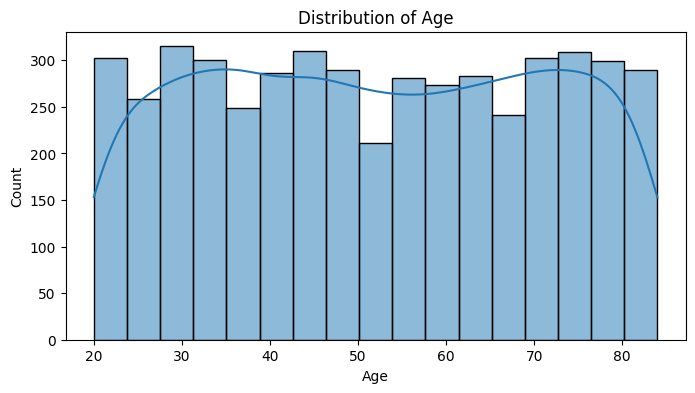

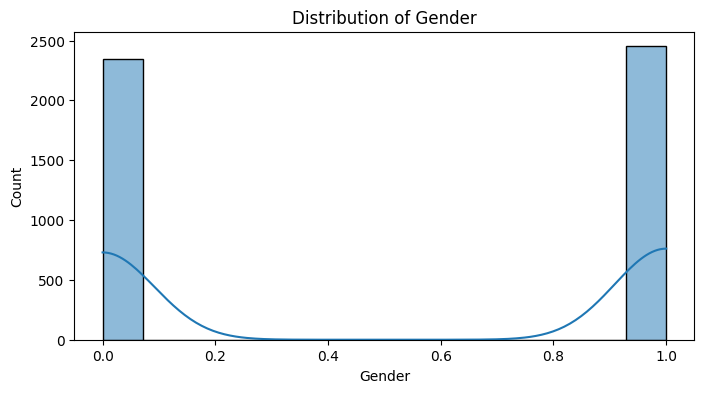

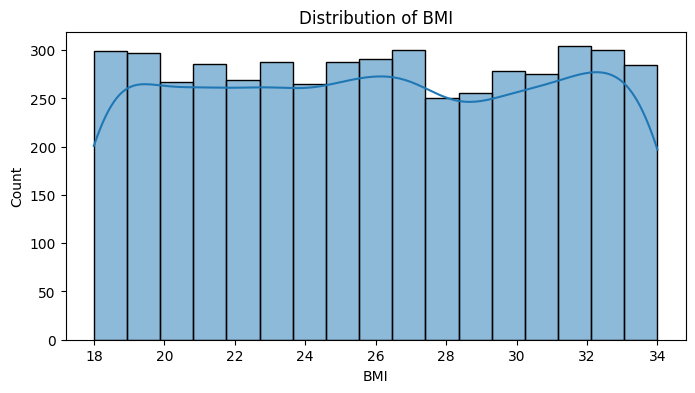

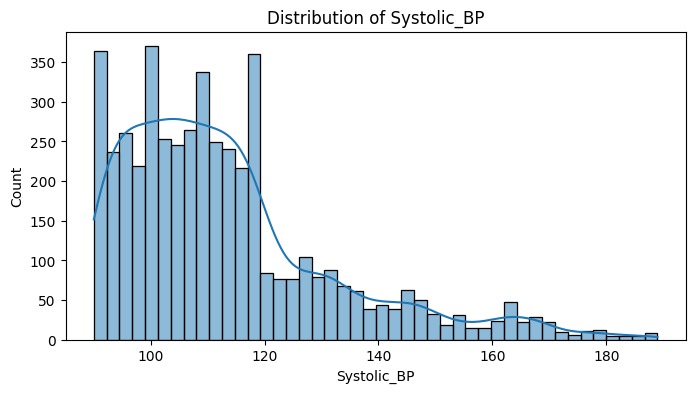

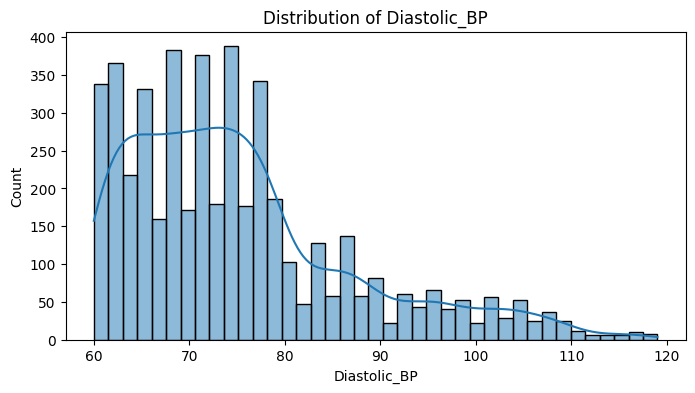

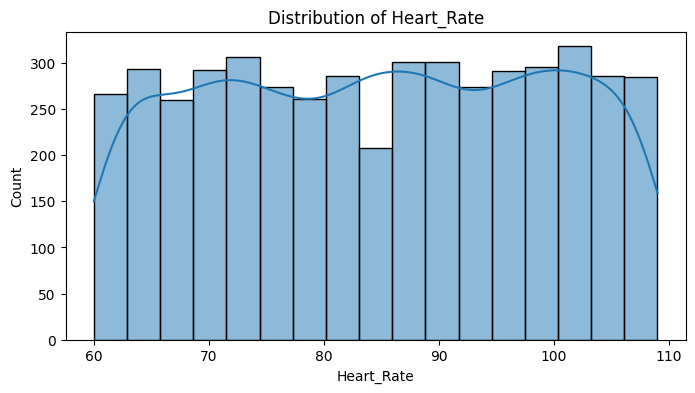

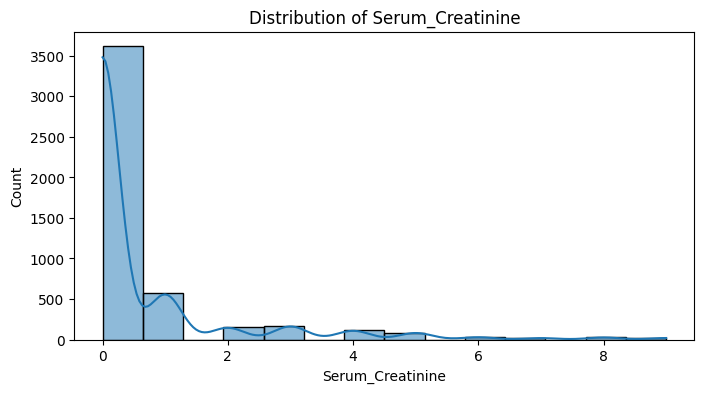

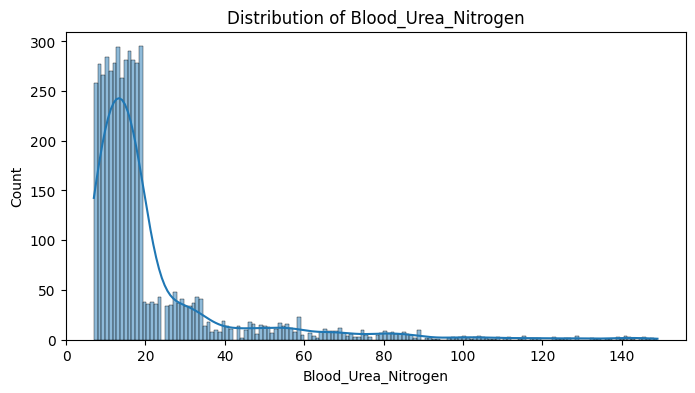

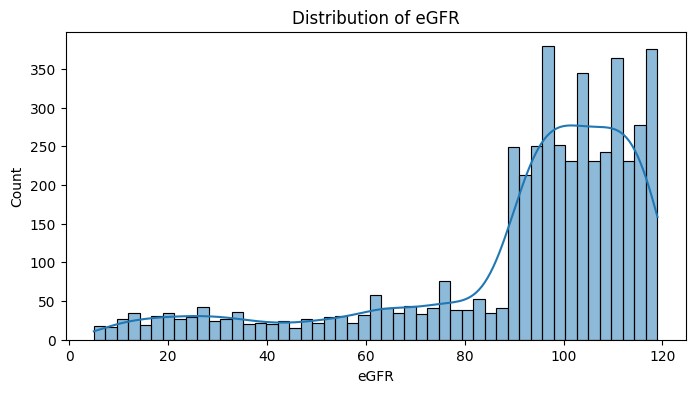

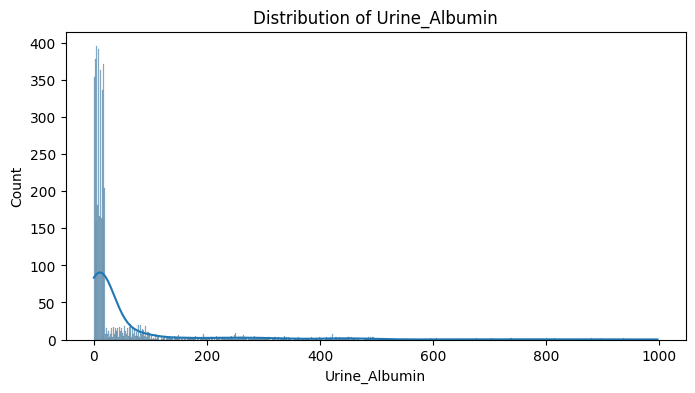

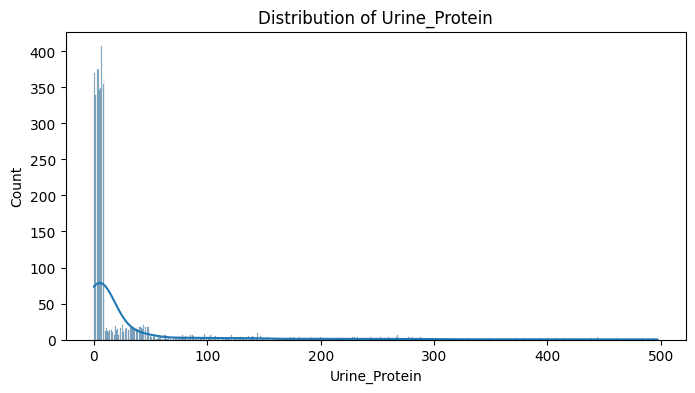

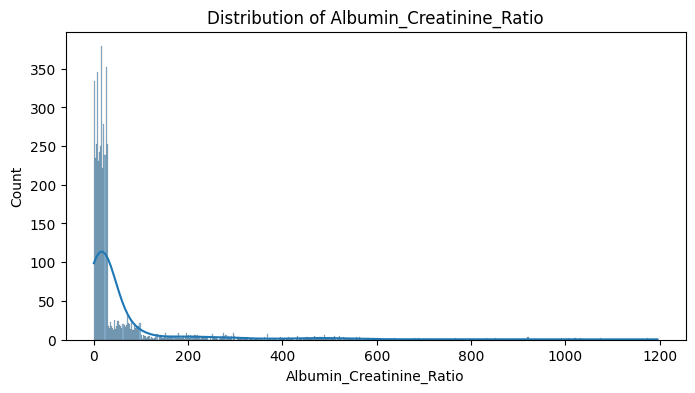

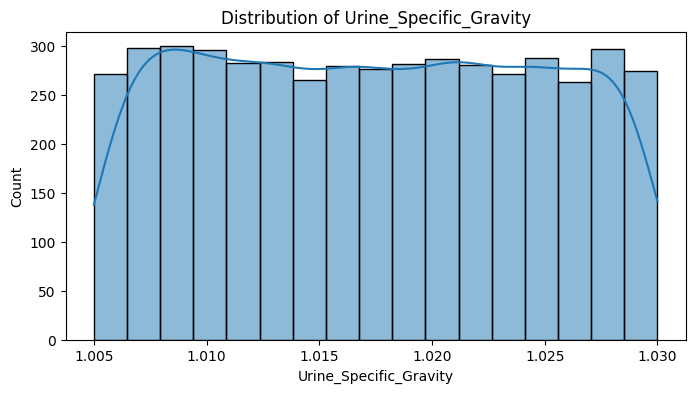

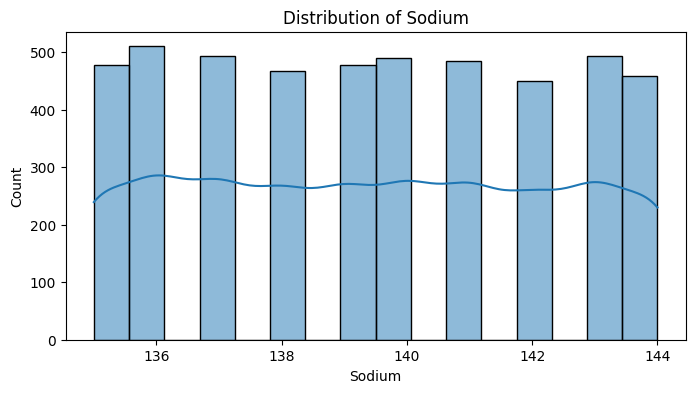

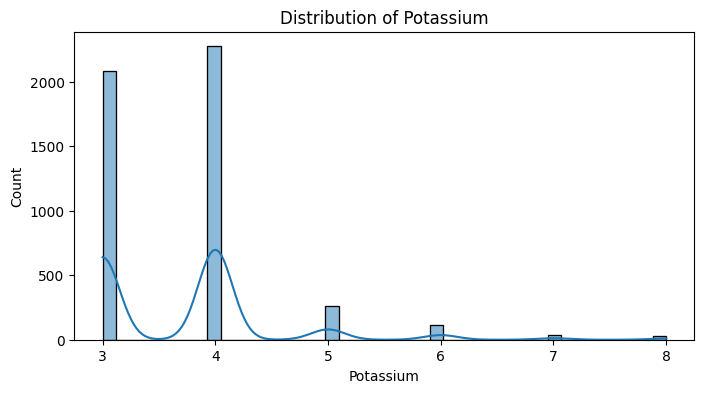

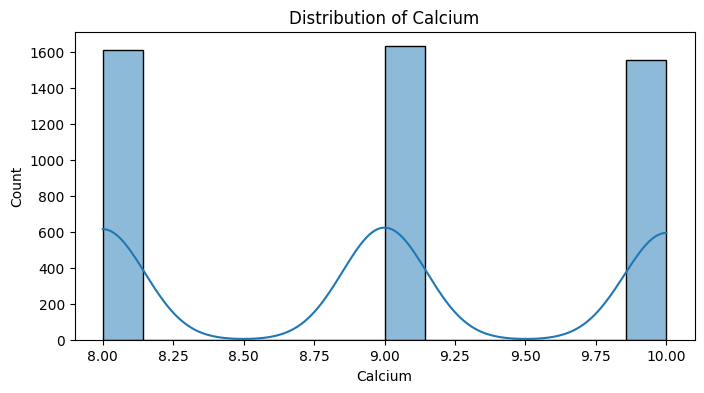

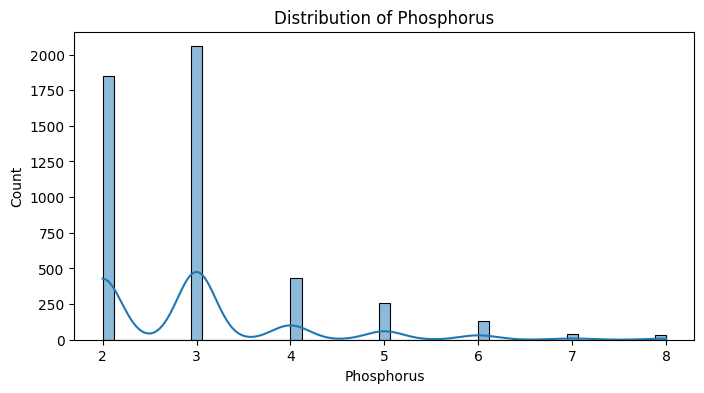

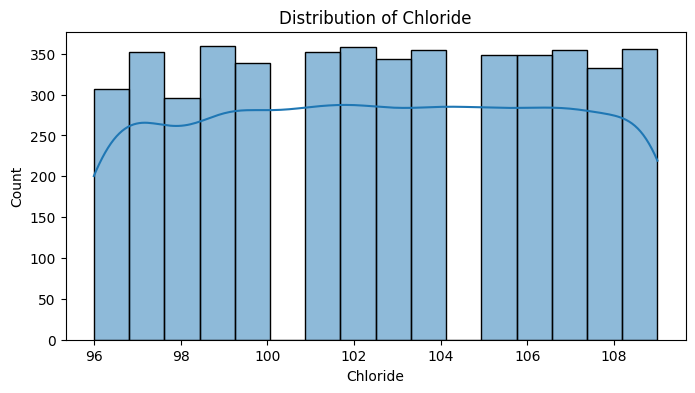

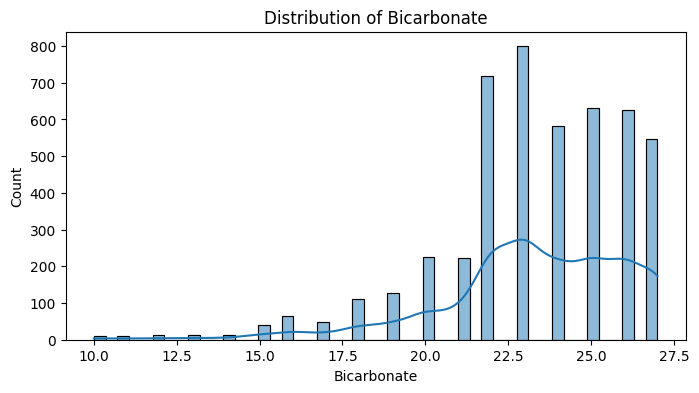

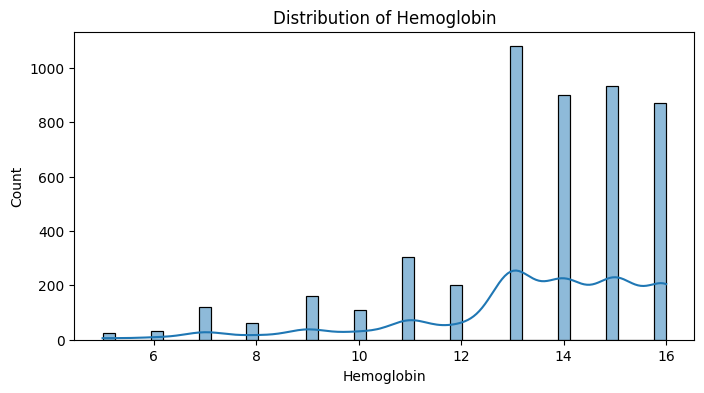

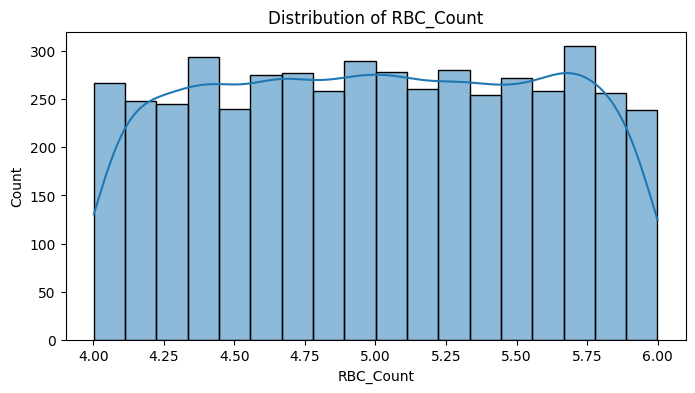

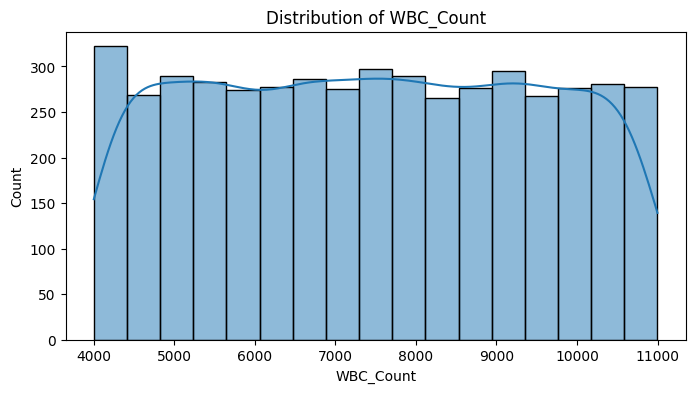

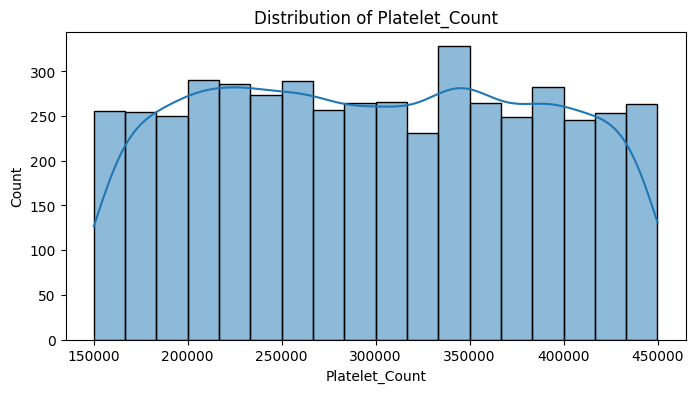

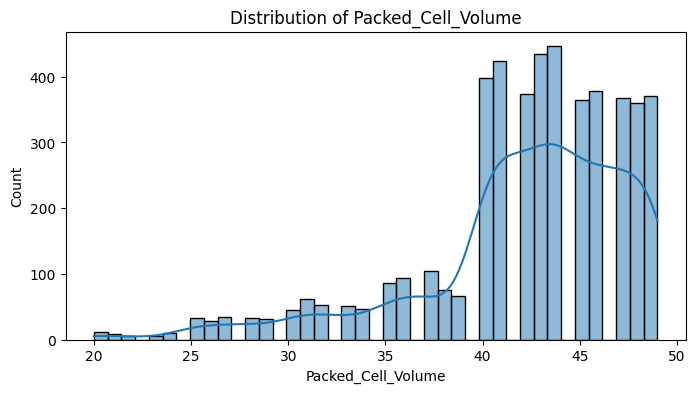

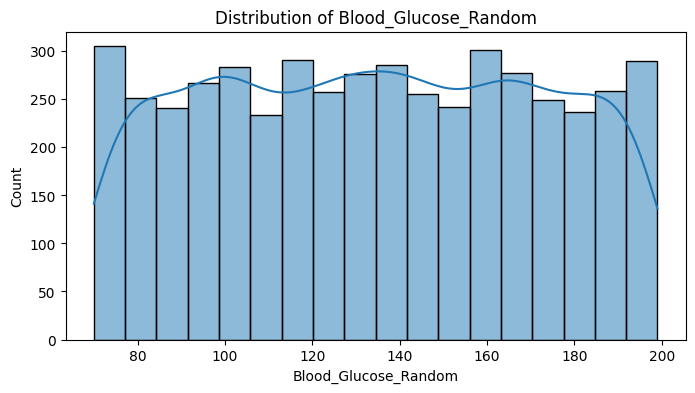

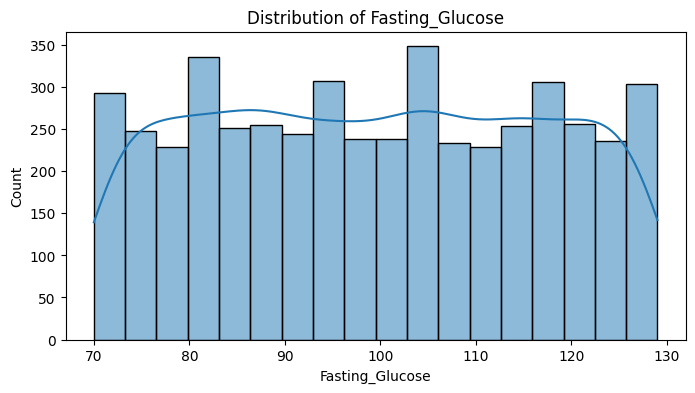

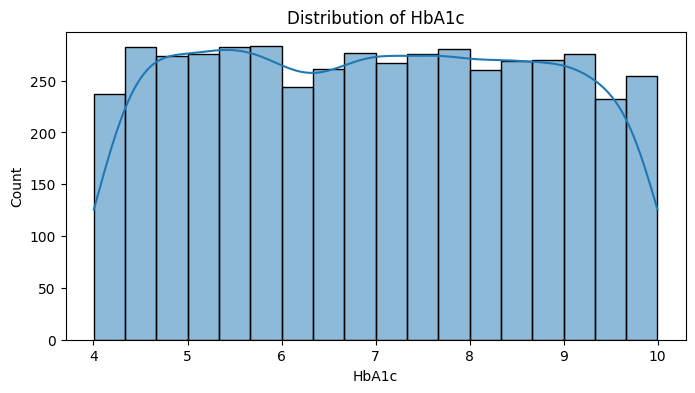

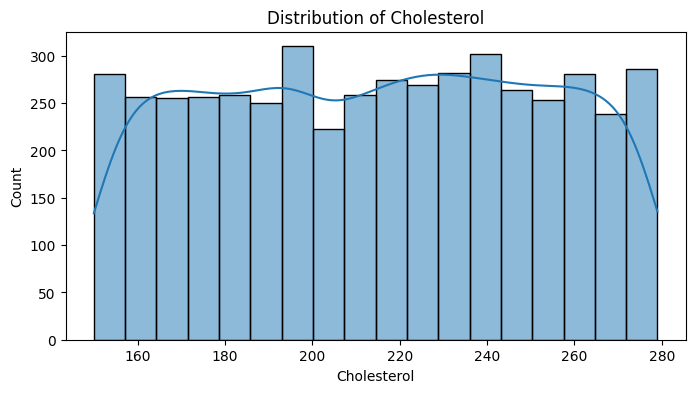

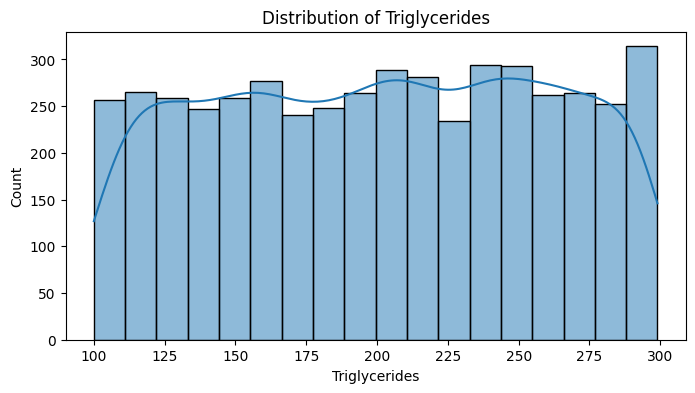

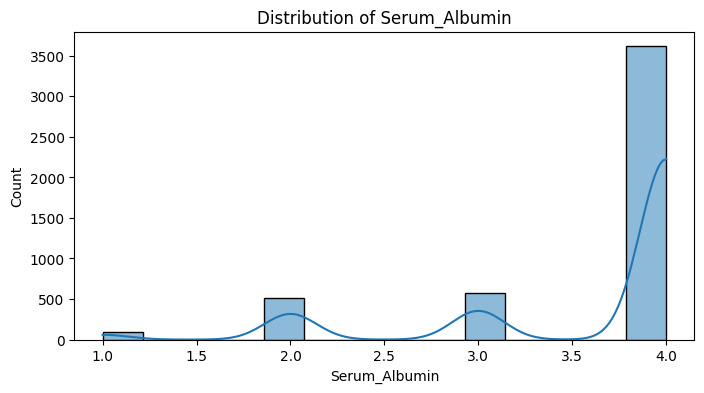

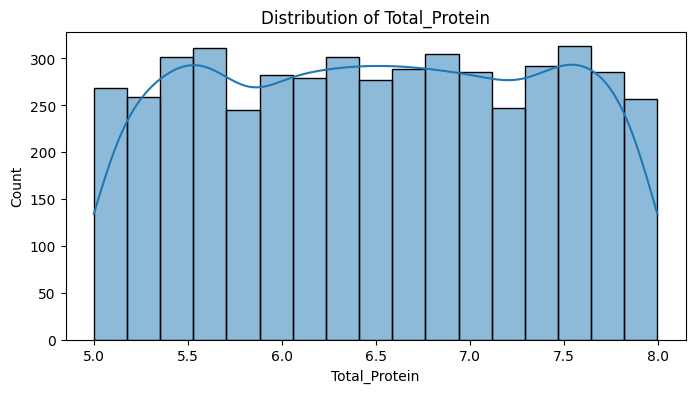

In [12]:
#plot distribution of all numeric features
numeric_features = df_train.select_dtypes(include=[np.number]).columns
for feature in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_train[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.show()

### it seem that data is tends to both `left skeweness` and `uniform distruption`

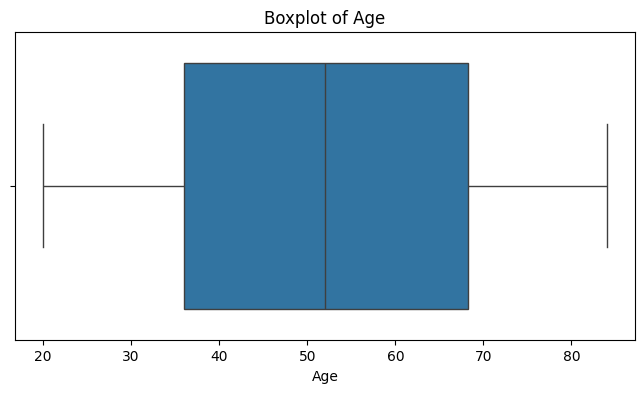

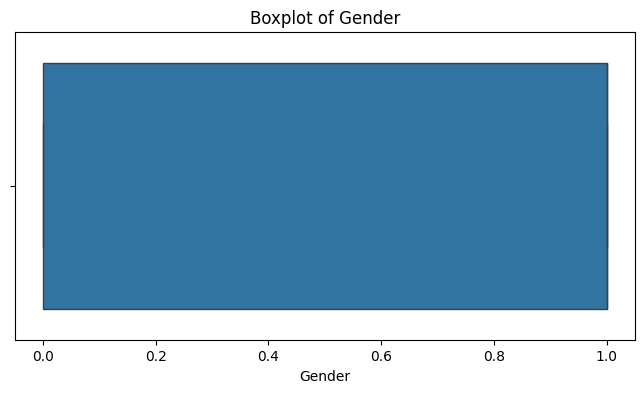

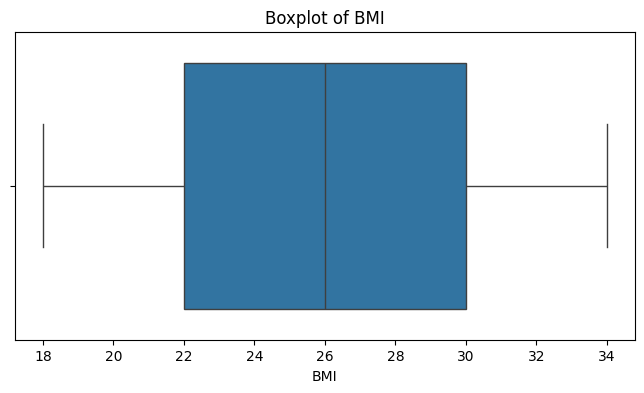

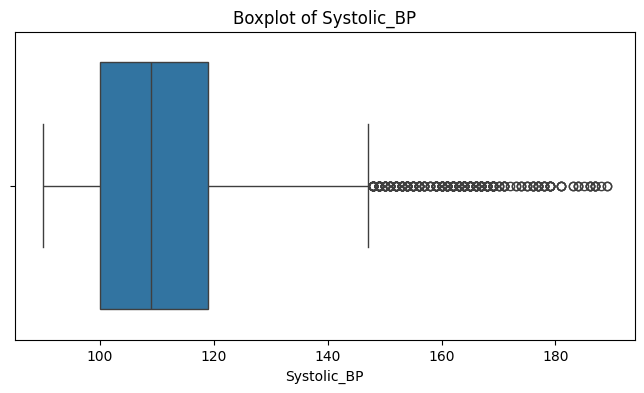

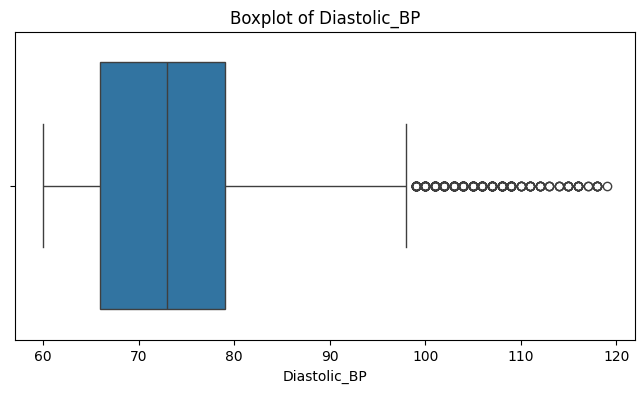

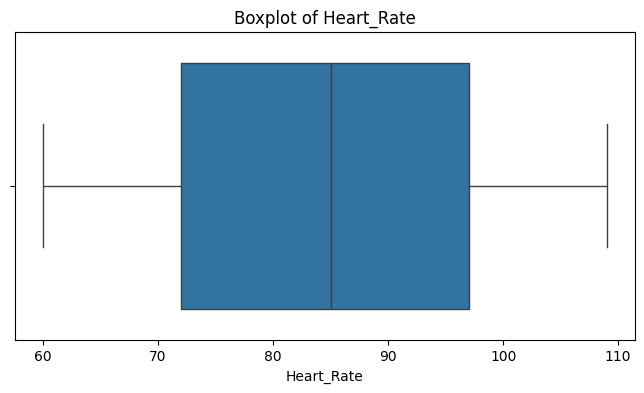

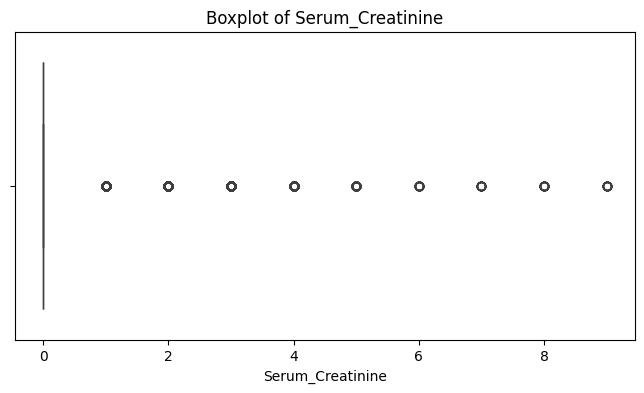

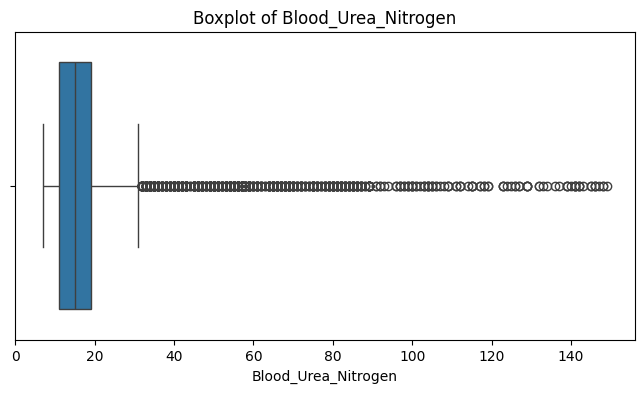

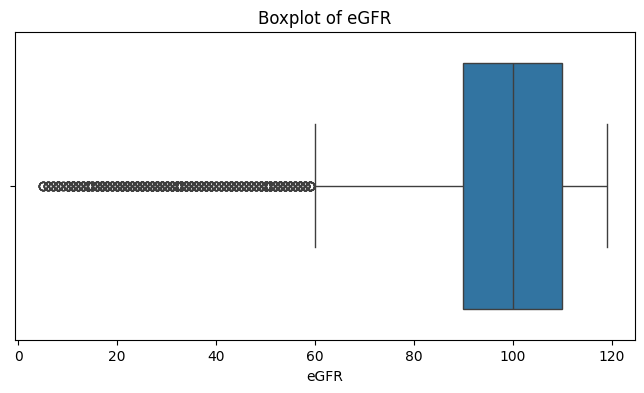

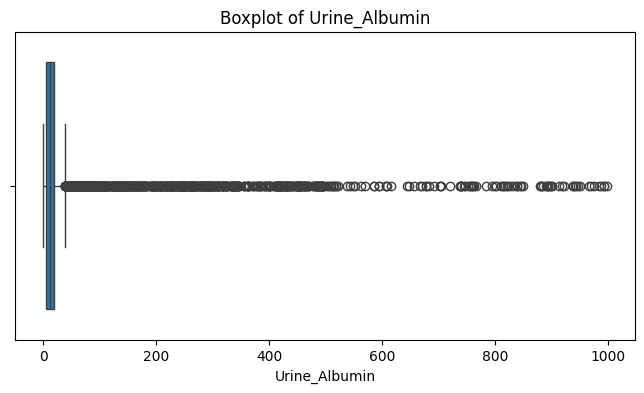

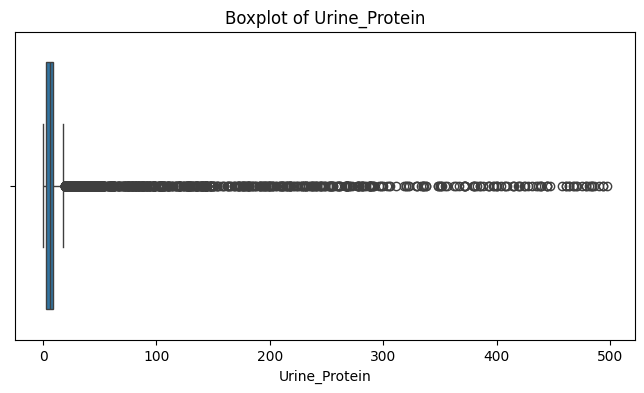

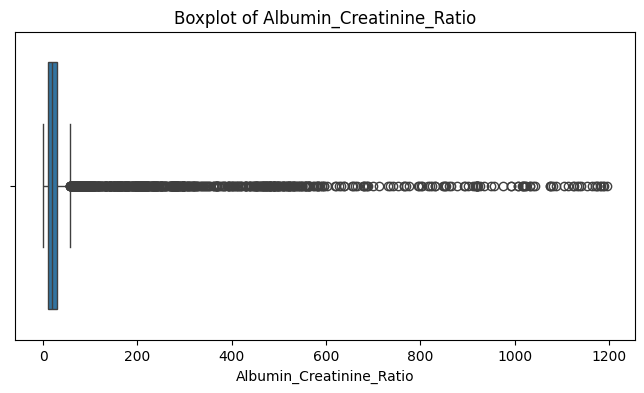

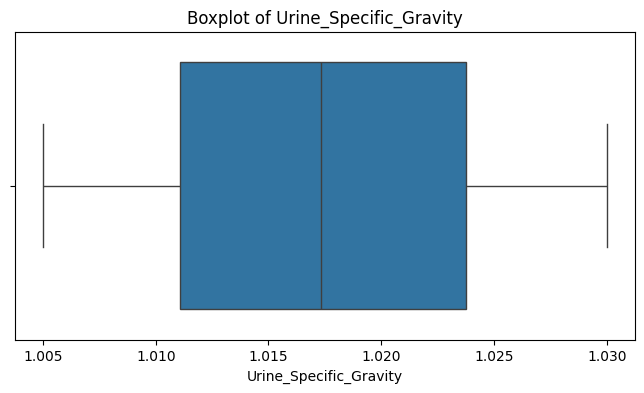

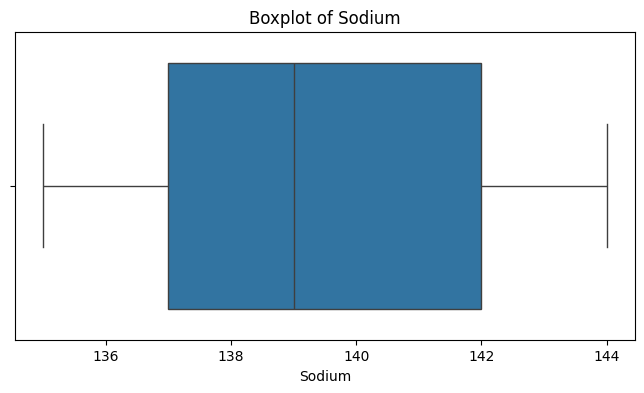

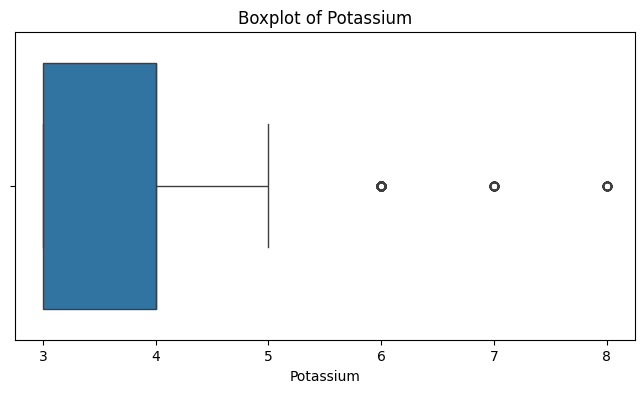

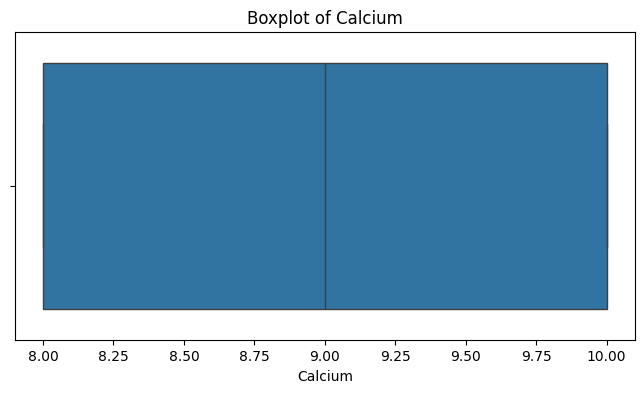

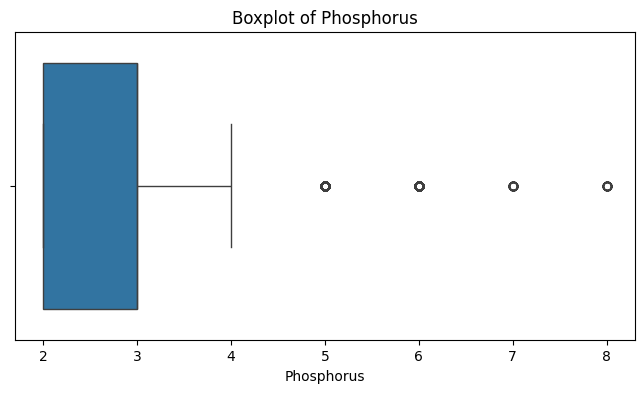

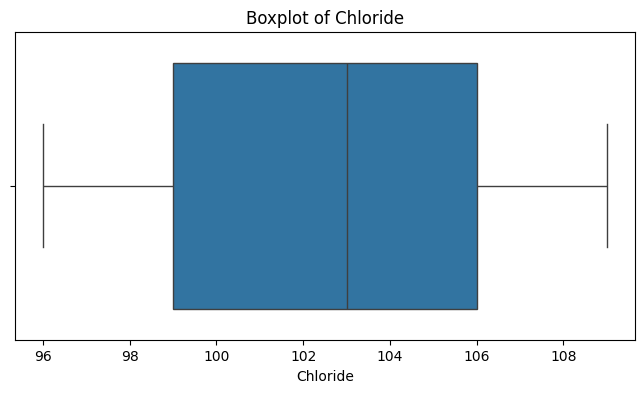

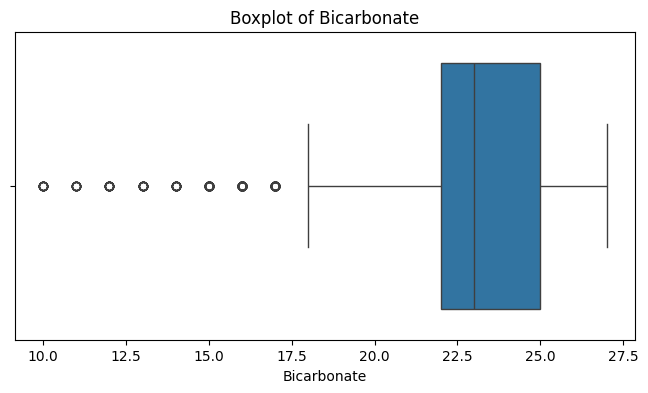

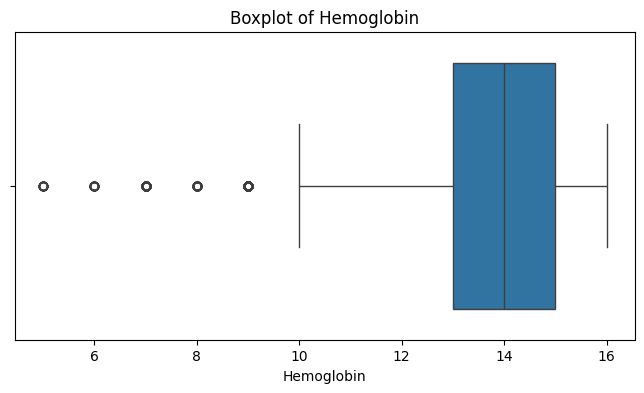

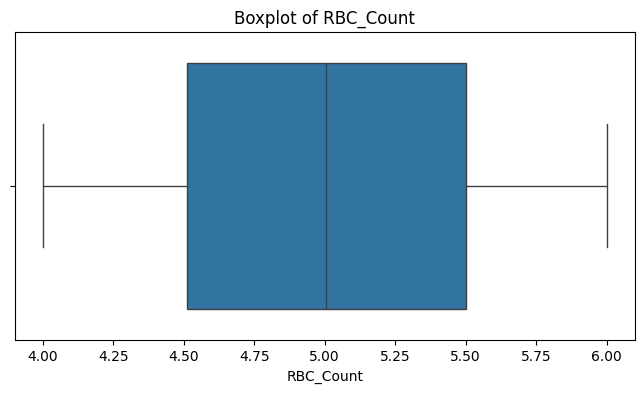

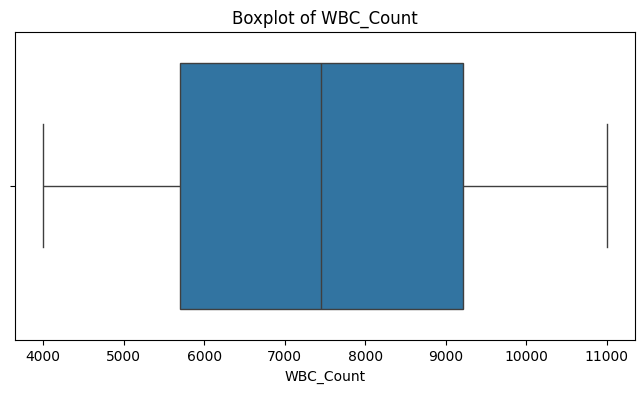

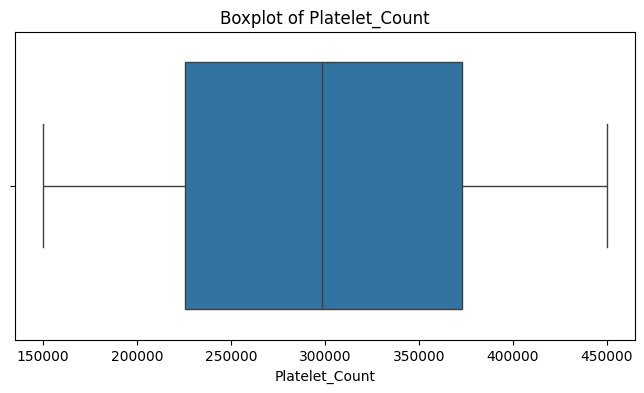

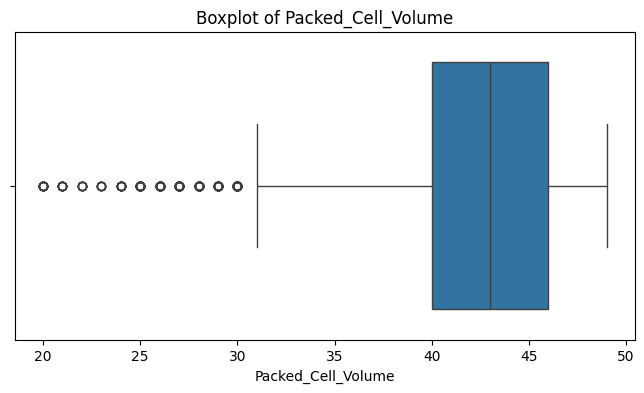

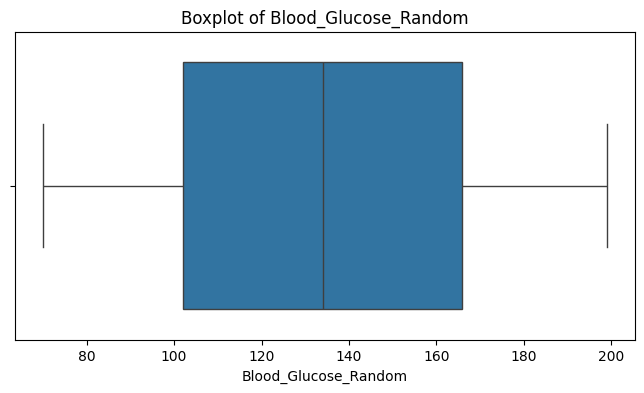

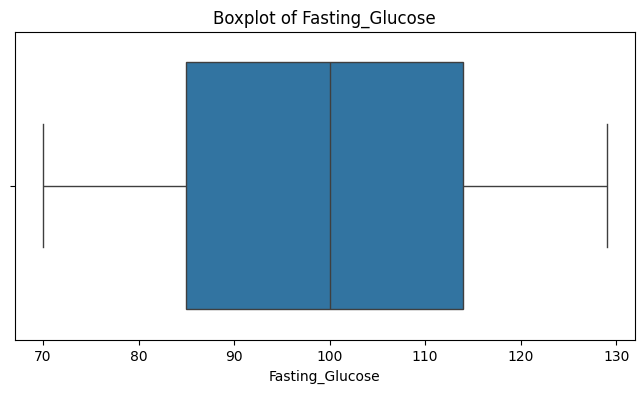

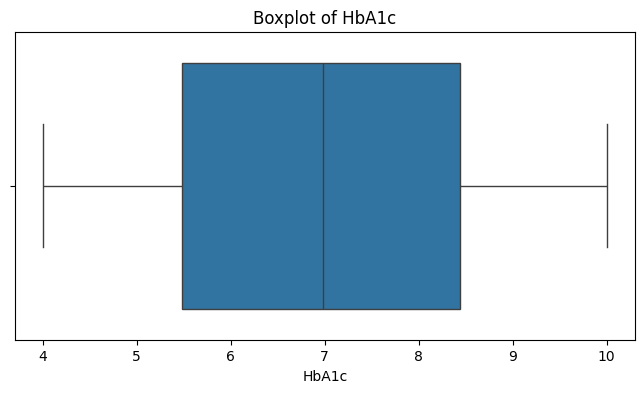

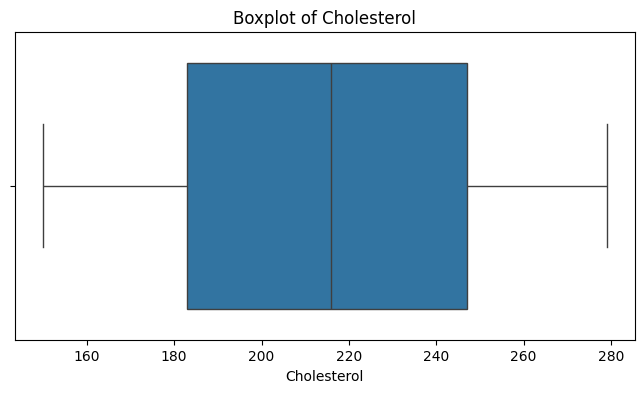

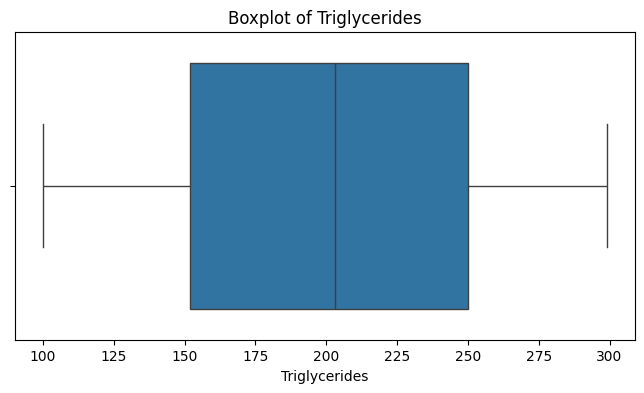

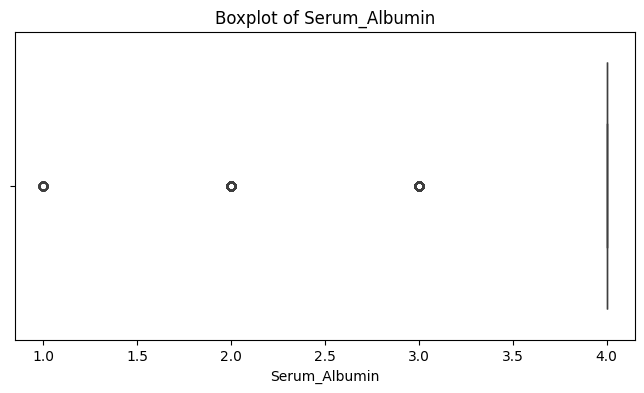

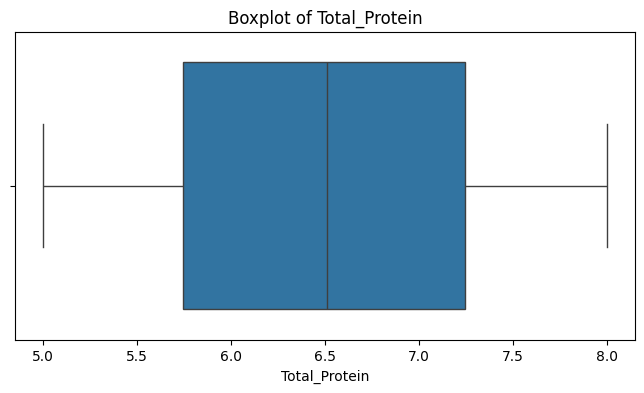

In [13]:
#Check for outliers using boxplots
for feature in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_train[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

In [14]:
#Apply log transformation to skewed features
# 1. Systolic_BP
# 2. Diastolic_BP
# 3. Blood_Urea_Nitrogen
# 4. eGFR
# 5. Urine_Albumin
# 6. Urine_Protein
# 7. Albumin_Creatinine_Ratio
skewed_features = ['Systolic_BP', 'Diastolic_BP', 'Blood_Urea_Nitrogen', 'eGFR', 'Urine_Albumin', 'Urine_Protein', 'Albumin_Creatinine_Ratio']
for feature in skewed_features:
    df_train[feature] = np.log1p(df_train[feature])

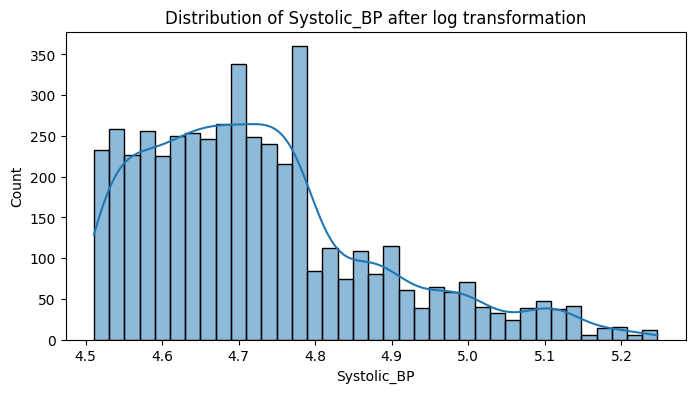

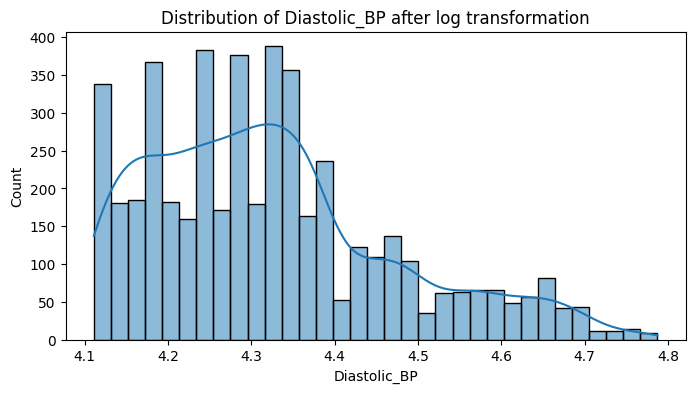

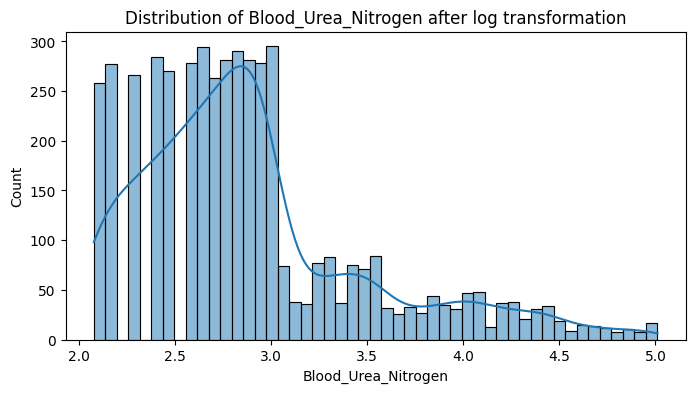

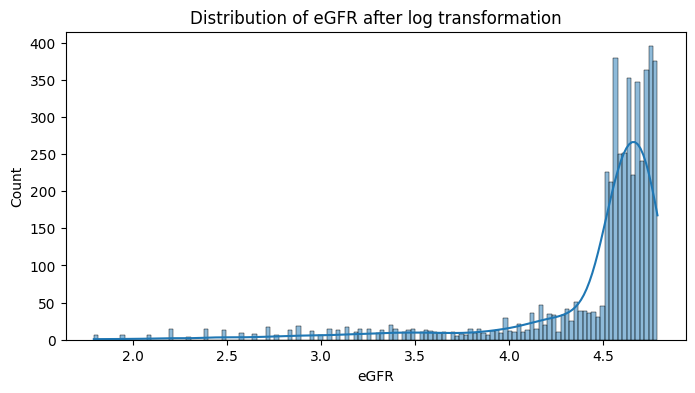

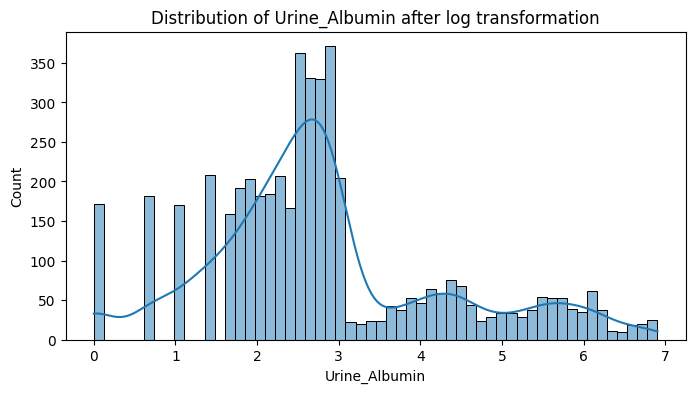

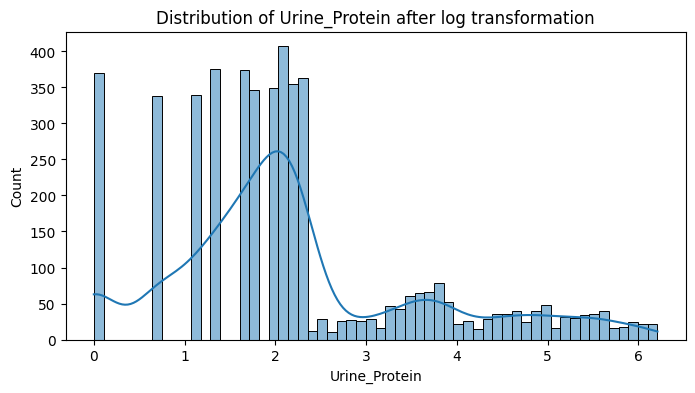

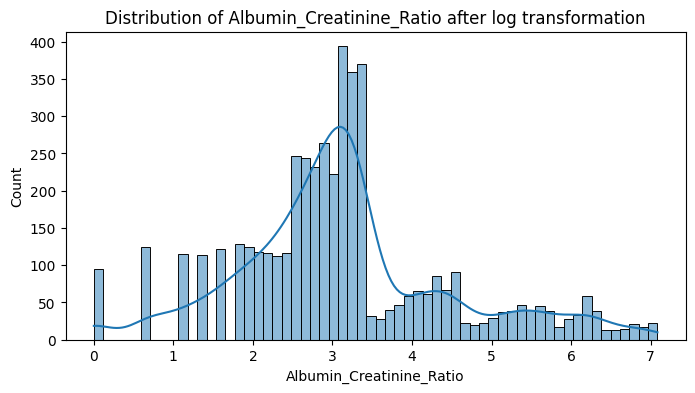

In [16]:
#plotting the ditribution of the skewed features after log transformation
for feature in skewed_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_train[feature], kde=True)
    plt.title(f'Distribution of {feature} after log transformation')
    plt.show()

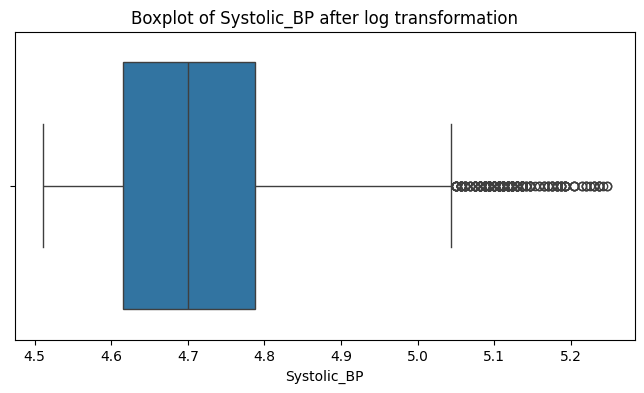

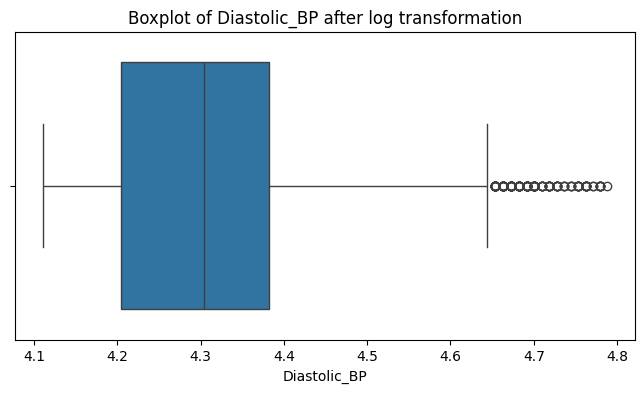

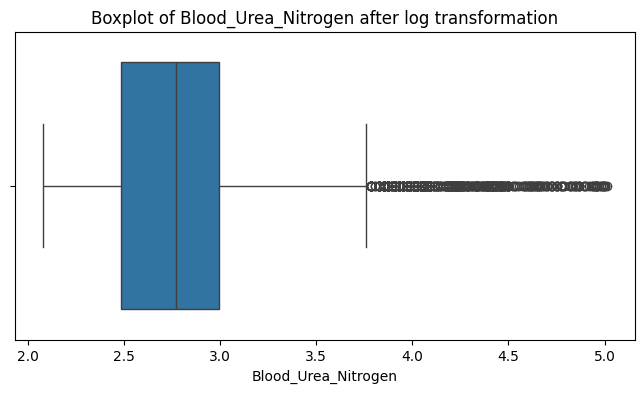

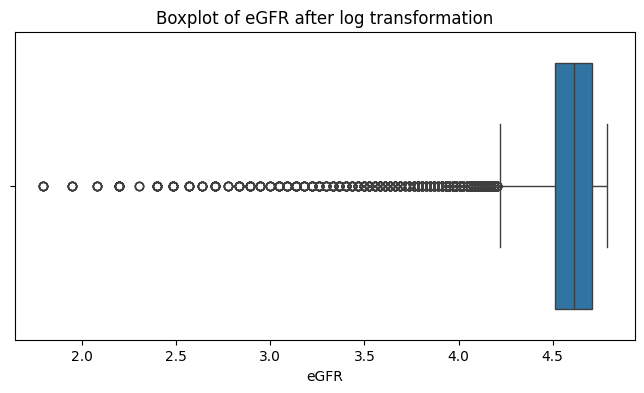

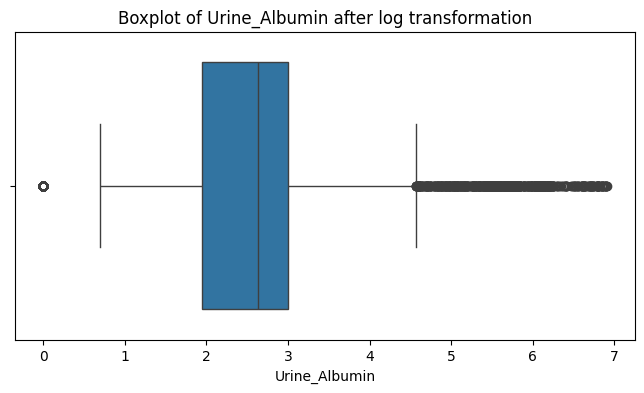

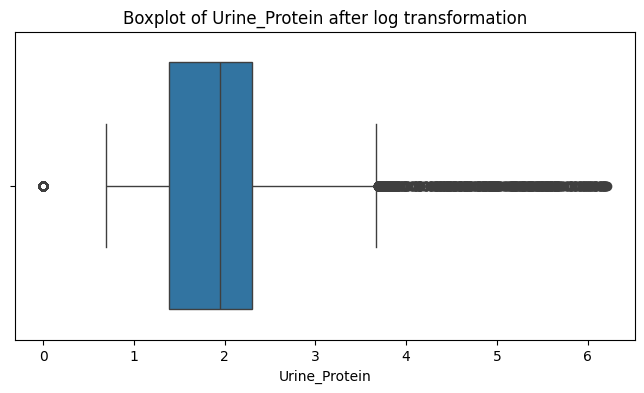

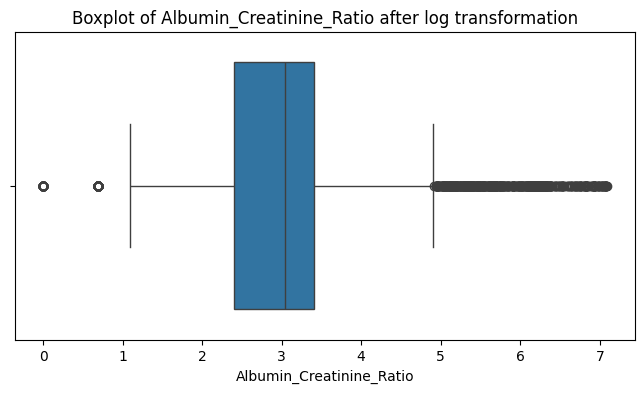

In [18]:
#Draw boxplots for the skewed features after log transformation
for feature in skewed_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_train[feature])
    plt.title(f'Boxplot of {feature} after log transformation')
    plt.show()

### okay it seem that the effect of outlier data is become less

## Feature Engineering

### Now,Check correlation

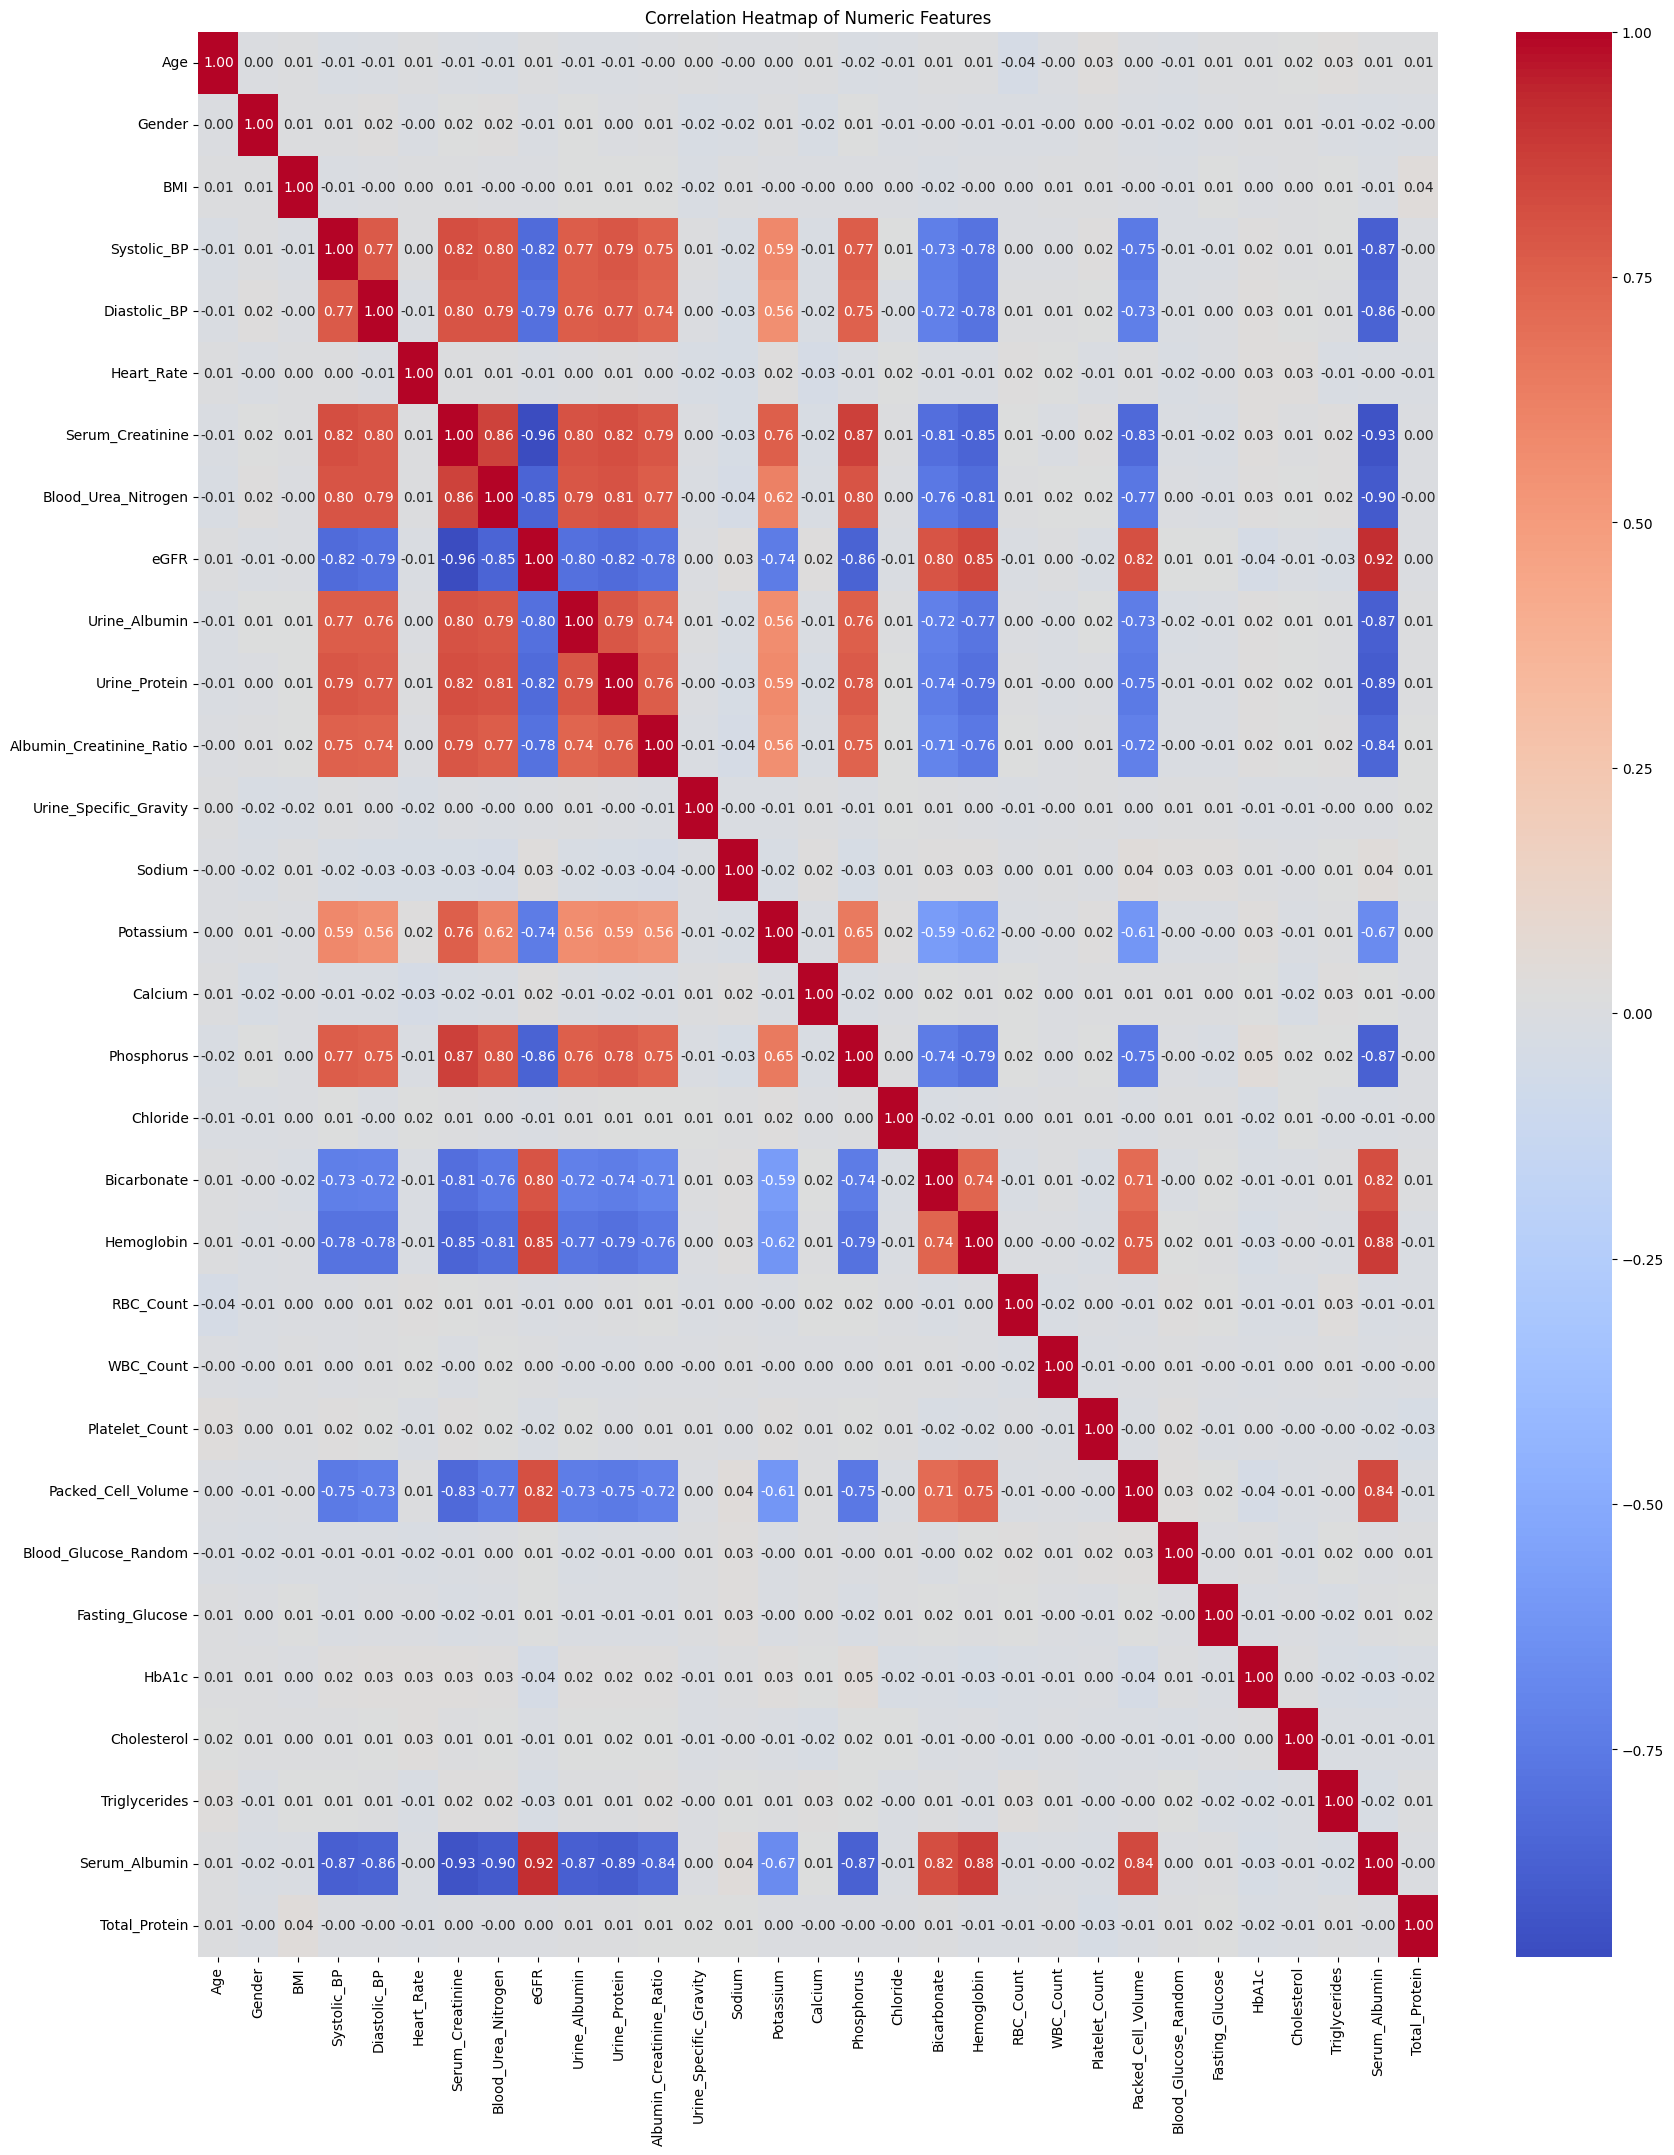

In [24]:
#correlation heatmap for numeric features
plt.figure(figsize=(20, 25))
numeric_features = df_train.select_dtypes(include=[np.number])
correlation_matrix = numeric_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

### We can see that data contain multicolinearity 

### Encode Featurs that contain {'Yes':1,'No':0}

In [26]:
#encode  ["Diabetes","Hypertension","Smoking_Status","Family_History_Kidney"] columns {'Yes': 1, 'No': 0}
df_train['Diabetes'] = df_train['Diabetes'].map({'Yes': 1, 'No': 0})
df_train['Hypertension'] = df_train['Hypertension'].map({'Yes': 1, 'No': 0})
df_train['Smoking_Status'] = df_train['Smoking_Status'].map({'Yes': 1, 'No': 0})
df_train['Family_History_Kidney'] = df_train['Family_History_Kidney'].map({'Yes': 1, 'No': 0})


In [27]:
df_train

,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,38,0,33,4.744932,4.369448,78,0,2.397895,4.770685,...,97,4.677411,211,203,4,5.156141,0,0,1,0
1,Severe CKD (Stage 4),76,0,28,5.117994,4.644391,92,5,4.442651,3.258097,...,111,9.490302,194,210,2,7.922118,0,0,0,0
2,Healthy Kidney,63,0,33,4.700480,4.382027,98,0,2.890372,4.700480,...,125,6.023745,243,138,4,6.606848,0,0,0,1
3,Healthy Kidney,54,0,31,4.682131,4.143135,109,0,2.397895,4.682131,...,127,5.772014,163,276,4,6.651897,0,1,0,1
4,Healthy Kidney,20,0,20,4.718499,4.158883,92,0,2.890372,4.584967,...,127,8.483288,221,264,4,6.400641,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4795,Healthy Kidney,63,0,24,4.644391,4.369448,91,0,2.639057,4.510860,...,109,9.231548,261,249,4,6.740736,0,1,0,0
4796,Healthy Kidney,79,1,21,4.624973,4.317488,95,0,2.944439,4.779123,...,97,7.085726,166,187,4,5.675948,0,0,1,1
4797,Mild CKD (Stage 1–2),82,1,26,4.852030,4.454347,93,1,3.218876,4.442651,...,82,9.145745,268,139,3,6.410811,1,0,1,1
4798,Healthy Kidney,24,1,32,4.605170,4.127134,84,0,2.890372,4.553877,...,98,9.126159,174,161,4,7.071250,0,1,0,0


### see target unique values

In [29]:
#see target unique values and their counts
print(df_train['Target'].value_counts())

Target
Healthy Kidney              3615
Mild CKD (Stage 1–2)         575
Moderate CKD (Stage 3)       318
Severe CKD (Stage 4)         196
Kidney Failure (Stage 5)      96
Name: count, dtype: int64


### Draw Class Count

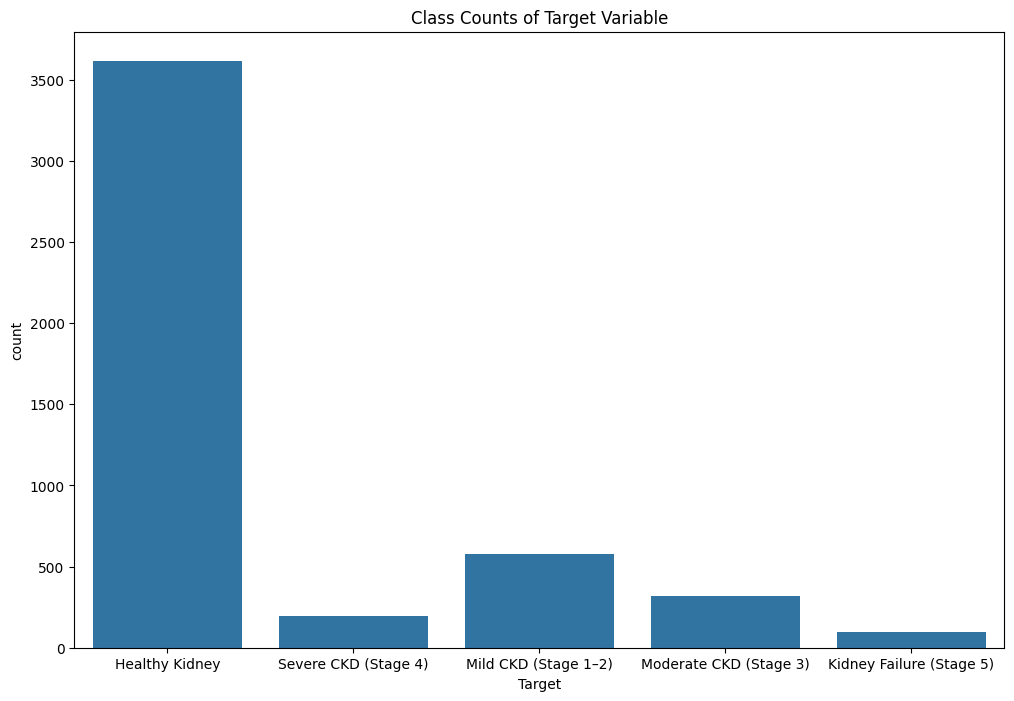

In [31]:
#Draw class Counts
plt.figure(figsize=(12, 8))
sns.countplot(x='Target', data=df_train)
plt.title('Class Counts of Target Variable')
plt.show()

### We can counclude that data is imbalanced so we will deal with weighted data

### set `class_weight='balanced'`

### Advanced Feature Enginering

### Handle Multicollinearity (Drop Redundant Features)
Based on the correlation heatmap, we are dropping features that are highly correlated with others to reduce multicollinearity:
* Dropping `Packed_Cell_Volume` (kept `Hemoglobin`)
* Dropping `Blood_Urea_Nitrogen` (kept `Serum_Creatinine`)
* Dropping `Urine_Protein` and `Albumin_Creatinine_Ratio` (kept `Urine_Albumin`)

In [32]:
# List of highly correlated features to drop
columns_to_drop = [
    'Packed_Cell_Volume', 
    'Blood_Urea_Nitrogen', 
    'Urine_Protein', 
    'Albumin_Creatinine_Ratio'
]

# Drop the columns from the training dataset
df_train = df_train.drop(columns=columns_to_drop)

# Verify the columns were dropped
print(f"Remaining number of columns: {df_train.shape[1]}")

Remaining number of columns: 32


### Encode `Target` feature

In [33]:
# encode Target using ordinal encoding from sklearn
# Healthy Kidney              3615
# Mild CKD (Stage 1–2)         575
# Moderate CKD (Stage 3)       318
# Severe CKD (Stage 4)         196
# Kidney Failure (Stage 5)      96
# Name: count, dtype: int64
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder(categories=[['Healthy Kidney', 'Mild CKD (Stage 1–2)', 'Moderate CKD (Stage 3)', 'Severe CKD (Stage 4)', 'Kidney Failure (Stage 5)']])
df_train['Target'] = ordinal_encoder.fit_transform(df_train[['Target']])


### Saving preprocessed Data frame 

In [35]:
#save the cleaned and preprocessed training dataset to a new CSV file
df_train.to_csv('Cleaned_Training_CKD_dataset.csv', index=False)

## Start Modeling